In [1]:
!pip install pandas numpy torch scikit-learn matplotlib


  Using cached pandas-3.0.5-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
Using cached pandas-3.0.5-cp311-cp311-win_amd64.whl (10.0 MB)
Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl (9.3 MB)

   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   -------------------------------------

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!
Using device: cpu

Dataset loaded successfully!
Dataset shape: (50, 2)

First 5 reviews:
                                          review sentiment
0    The movie was excellent and very enjoyable.  positive
1  I loved this film and the acting was amazing.  positive
2    The story was interesting and well written.  positive
3     A wonderful movie with great performances.  positive
4               The actors did an excellent job.  positive

Dataset after removing missing values:
(50, 2)

Sentiment distribution:
sentiment
positive    25
negative    25
Name: count, dtype: int64

Example cleaned review:
the movie was excellent and very enjoyable

Tokenized example:
['the', 'movie', 'was', 'excellent', 'and', 'very', 'enjoyable']

Dataset split:
Training   : 32
Validation : 8
Testing    : 10

Vocabulary size: 100

Sequence shapes:
X_train: (32, 100)
X_val  : (8, 100)
X_test : (10, 100)

Model:
SentimentLSTM(
  (embedding): Embedding(100, 64, padding_idx=0)
  (

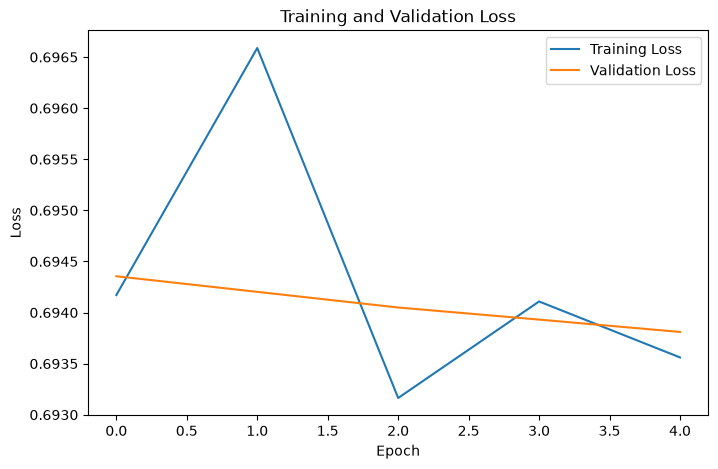



MODEL EVALUATION
Accuracy  : 50.00%
Precision : 0.00%
Recall    : 0.00%
F1-Score  : 0.00%


SAMPLE REVIEW PREDICTION
Review: The movie was excellent and very enjoyable.
Predicted Sentiment: Negative
Confidence: 51.82%


CUSTOM REVIEW SENTIMENT ANALYZER


In [ ]:
# ============================================================
# LSTM CUSTOMER REVIEW SENTIMENT ANALYZER
# PyTorch + IMDb-style Dataset
# ============================================================

import pandas as pd
import numpy as np
import re
import random

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt


# ============================================================
# 1. SET RANDOM SEEDS
# ============================================================

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Libraries loaded successfully!")


# ============================================================
# 2. SELECT DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)


# ============================================================
# 3. LOAD DATASET
# ============================================================

df = pd.read_csv("imdb_small.csv")

print("\nDataset loaded successfully!")

print("Dataset shape:", df.shape)

print("\nFirst 5 reviews:")
print(df.head())


# ============================================================
# 4. REMOVE MISSING VALUES
# ============================================================

df = df.dropna()

df = df[
    ["review", "sentiment"]
]

print("\nDataset after removing missing values:")
print(df.shape)


# ============================================================
# 5. CONVERT SENTIMENT TO NUMBERS
# ============================================================

df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())


# ============================================================
# 6. TEXT CLEANING FUNCTION
# ============================================================

def clean_text(text):

    text = text.lower()

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Keep only letters and spaces
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_review"] = df[
    "review"
].apply(clean_text)


print("\nExample cleaned review:")
print(df["clean_review"].iloc[0])


# ============================================================
# 7. TOKENIZATION
# ============================================================

def tokenize(text):

    return text.split()


df["tokens"] = df[
    "clean_review"
].apply(tokenize)


print("\nTokenized example:")
print(df["tokens"].iloc[0])


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)


# Split training data into training and validation
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)


print("\nDataset split:")
print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))


# ============================================================
# 9. CREATE VOCABULARY
# ============================================================

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

word_counts = {}

for tokens in train_df["tokens"]:

    for word in tokens:

        if word not in word_counts:
            word_counts[word] = 0

        word_counts[word] += 1


# Minimum frequency
MIN_FREQ = 1


vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}


for word, count in word_counts.items():

    if count >= MIN_FREQ:

        vocab[word] = len(vocab)


print("\nVocabulary size:", len(vocab))


# ============================================================
# 10. CONVERT WORDS TO INTEGER SEQUENCES
# ============================================================

def text_to_sequence(tokens):

    return [
        vocab.get(
            word,
            vocab[UNK_TOKEN]
        )
        for word in tokens
    ]


train_sequences = [
    text_to_sequence(tokens)
    for tokens in train_df["tokens"]
]

val_sequences = [
    text_to_sequence(tokens)
    for tokens in val_df["tokens"]
]

test_sequences = [
    text_to_sequence(tokens)
    for tokens in test_df["tokens"]
]


# ============================================================
# 11. PAD SEQUENCES
# ============================================================

MAX_LENGTH = 100


def pad_sequence(sequence):

    if len(sequence) > MAX_LENGTH:

        sequence = sequence[
            :MAX_LENGTH
        ]

    else:

        sequence = sequence + [
            vocab[PAD_TOKEN]
        ] * (
            MAX_LENGTH - len(sequence)
        )

    return sequence


X_train = np.array([
    pad_sequence(seq)
    for seq in train_sequences
])

X_val = np.array([
    pad_sequence(seq)
    for seq in val_sequences
])

X_test = np.array([
    pad_sequence(seq)
    for seq in test_sequences
])


# ============================================================
# 12. CREATE LABEL ARRAYS
# ============================================================

y_train = train_df[
    "label"
].values

y_val = val_df[
    "label"
].values

y_test = test_df[
    "label"
].values


print("\nSequence shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


# ============================================================
# 13. CONVERT TO PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)


# ============================================================
# 14. CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 32


train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 15. BUILD LSTM MODEL
# ============================================================

class SentimentLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=64,
        hidden_dim=64,
        num_layers=1,
        dropout=0.3
    ):

        super(
            SentimentLSTM,
            self
        ).__init__()


        # Embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )


        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(
                dropout
                if num_layers > 1
                else 0
            )
        )


        # Fully Connected layer
        self.fc = nn.Linear(
            hidden_dim,
            1
        )


        self.dropout = nn.Dropout(
            dropout
        )


    def forward(self, x):

        # Embedding
        embedded = self.embedding(x)


        # LSTM
        output, (hidden, cell) = (
            self.lstm(embedded)
        )


        # Take last hidden state
        hidden = hidden[-1]


        hidden = self.dropout(
            hidden
        )


        # Fully connected layer
        output = self.fc(hidden)


        return output.squeeze(1)


# ============================================================
# 16. CREATE MODEL
# ============================================================

model = SentimentLSTM(
    vocab_size=len(vocab),
    embedding_dim=64,
    hidden_dim=64,
    num_layers=1,
    dropout=0.3
)


model = model.to(device)


print("\nModel:")
print(model)


# ============================================================
# 17. LOSS FUNCTION AND OPTIMIZER
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# ============================================================
# 18. TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=5
):

    train_losses = []
    val_losses = []


    for epoch in range(epochs):

        # -----------------------------
        # Training
        # -----------------------------

        model.train()

        total_train_loss = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)


            optimizer.zero_grad()


            outputs = model(
                inputs
            )


            loss = criterion(
                outputs,
                labels
            )


            loss.backward()


            optimizer.step()


            total_train_loss += (
                loss.item()
            )


        avg_train_loss = (
            total_train_loss
            / len(train_loader)
        )


        # -----------------------------
        # Validation
        # -----------------------------

        model.eval()

        total_val_loss = 0


        with torch.no_grad():

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)


                outputs = model(
                    inputs
                )


                loss = criterion(
                    outputs,
                    labels
                )


                total_val_loss += (
                    loss.item()
                )


        avg_val_loss = (
            total_val_loss
            / len(val_loader)
        )


        train_losses.append(
            avg_train_loss
        )

        val_losses.append(
            avg_val_loss
        )


        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"| Train Loss: "
            f"{avg_train_loss:.4f} "
            f"| Validation Loss: "
            f"{avg_val_loss:.4f}"
        )


    return train_losses, val_losses


# ============================================================
# 19. TRAIN MODEL
# ============================================================

EPOCHS = 5


train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS
)


# ============================================================
# 20. PLOT TRAINING / VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.show()


# ============================================================
# 21. TEST MODEL
# ============================================================

model.eval()

all_predictions = []
all_labels = []


with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)


        outputs = model(
            inputs
        )


        probabilities = torch.sigmoid(
            outputs
        )


        predictions = (
            probabilities >= 0.5
        ).int()


        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )


# ============================================================
# 22. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)


# ============================================================
# 23. DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n")
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1-Score  : {f1 * 100:.2f}%"
)


# ============================================================
# 24. FUNCTION TO PREDICT NEW REVIEW
# ============================================================

def predict_sentiment(review):

    # Clean review
    cleaned = clean_text(
        review
    )


    # Tokenize
    tokens = tokenize(
        cleaned
    )


    # Convert to integers
    sequence = text_to_sequence(
        tokens
    )


    # Pad
    sequence = pad_sequence(
        sequence
    )


    # Convert to tensor
    tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(device)


    # Prediction
    model.eval()


    with torch.no_grad():

        output = model(
            tensor
        )


        probability = torch.sigmoid(
            output
        ).item()


    # Sentiment
    if probability >= 0.5:

        sentiment = "Positive"

        confidence = probability

    else:

        sentiment = "Negative"

        confidence = 1 - probability


    return sentiment, confidence


# ============================================================
# 25. REQUIRED SAMPLE INPUT
# ============================================================

review = (
    "The movie was excellent and very enjoyable."
)


sentiment, confidence = (
    predict_sentiment(review)
)


print("\n")
print("=" * 50)
print("SAMPLE REVIEW PREDICTION")
print("=" * 50)

print(
    "Review:",
    review
)

print(
    "Predicted Sentiment:",
    sentiment
)

print(
    f"Confidence: "
    f"{confidence * 100:.2f}%"
)


# ============================================================
# 26. USER INPUT
# ============================================================

print("\n")
print("=" * 50)
print("CUSTOM REVIEW SENTIMENT ANALYZER")
print("=" * 50)

user_review = input(
    "Enter a movie/product review: "
)


if user_review.strip():

    sentiment, confidence = (
        predict_sentiment(
            user_review
        )
    )


    print("\nPredicted Sentiment:")
    print(sentiment)


    print(
        f"Confidence: "
        f"{confidence * 100:.2f}%"
    )

else:

    print(
        "No review entered."
    )